# 414 â€” Depth-Varying Manning's n for HEC-RAS 2D Models

Manning's roughness coefficient varies with flow depth â€” this is well-established
in hydraulic literature (Chow 1959, HEC-15, Limerinos 1970, Jarrett 1984) but
often ignored in practice because HEC-RAS 2D models default to uniform roughness.

This notebook demonstrates a complete workflow for implementing **depth-varying
Manning's n** in HEC-RAS 2D face property tables using `ras-commander`:

1. **Literature grounding** â€” formulas that relate n to hydraulic radius
2. **Geometry preprocessing** â€” generate face property tables from HEC-RAS
3. **Depth-varying n application** â€” replace uniform n with a depth-dependent formula
4. **Face property table extension** â€” extend tables to higher elevations with
   depth-varying n using the HEC-15 vegetal retardance concept
5. **Spatial filtering** â€” strategies for limiting modifications to channel faces

**Key insight**: HEC-RAS 2D face property tables store Manning's n as a function
of elevation for each cell face. By modifying these tables with a depth-varying
formula and **extending** them to higher elevations, we can model the physical
reality that roughness decreases with increasing flow depth.

**API methods demonstrated**:

| Method | Purpose |
|--------|---------|
| `GeomStorage.get/set_2d_flow_area_settings()` | Uniform Manning's n in `.g##` |
| `HdfMesh.get_mesh_face_property_tables()` | Read face-level n from geometry HDF |
| `HdfMesh.set_face_mannings_n_values()` | Replace n column with custom function |
| `HdfMesh.extend_face_property_tables()` | Extend tables to higher elevations |
| `HdfMesh.get_face_ids_in_polygon()` | Spatial filter: faces within a polygon |
| `HdfMesh.get_face_ids_in_calibration_region()` | Filter by named calibration region |
| `HdfMesh.pin_property_tables()` | Set Pinned attribute on mesh group |

## Workflow Overview

```mermaid
flowchart LR
    A[Read Geometry<br/>Settings] --> B[Preprocess<br/>Geometry]
    B --> C[Read Face<br/>Property Tables]
    C --> D[Apply Depth-<br/>Varying n]
    D --> E[Extend Tables<br/>Higher Elevations]
    E --> F[Pin Tables]
    F --> G[Spatial Filtering<br/>Options]

    style A fill:#e1f5fe
    style D fill:#fff3e0
    style E fill:#fff3e0
    style G fill:#e8f5e9
```

The critical steps are **D** and **E** â€” we replace the uniform Manning's n
in each face's property table with a depth-varying formula, then extend the
tables above the preprocessed terrain elevation so HEC-RAS has depth-varying
roughness data for deep flood events.

## Literature: Why Manning's n Varies with Depth

Manning's n is **not a constant** â€” it varies with the ratio of flow depth to
roughness element size (relative roughness R/k_s). At shallow depths, roughness
elements dominate the water column and form drag is high. At greater depths,
skin friction dominates and effective roughness decreases.

> *"If the depth of flow is shallow in relation to the size of the roughness
> elements, the n value can be large, and the n value decreases with
> increasing depth."* â€” Chow, V.T., 1959. *Open-Channel Hydraulics*

### Key Formulas

**HEC-15 Vegetal Retardance** (FHWA, [HEC-15 3rd Ed. 2005](https://www.fhwa.dot.gov/engineering/hydraulics/pubs/05114/05114.pdf)):

$$n = \frac{R^{1/6}}{X + 19.97 \cdot \log(R^{1.4} \cdot S^{0.4})}$$

where X is a retardance class coefficient (A=15.8 through E=37.7).

**Limerinos (1970)** ([USGS WSP 1898-B](https://pubs.usgs.gov/wsp/1898b/report.pdf)) â€” gravel-bed rivers:

$$n = \frac{0.0926 \cdot R^{1/6}}{1.16 + 2.0 \cdot \log_{10}(R/d_{84})}$$

**Jarrett (1984)** â€” high-gradient streams (S > 0.002):

$$n = 0.39 \cdot S^{0.38} \cdot R^{-0.16}$$

All three formulas show that **n decreases as hydraulic radius R (a proxy for
depth) increases** relative to roughness element size.

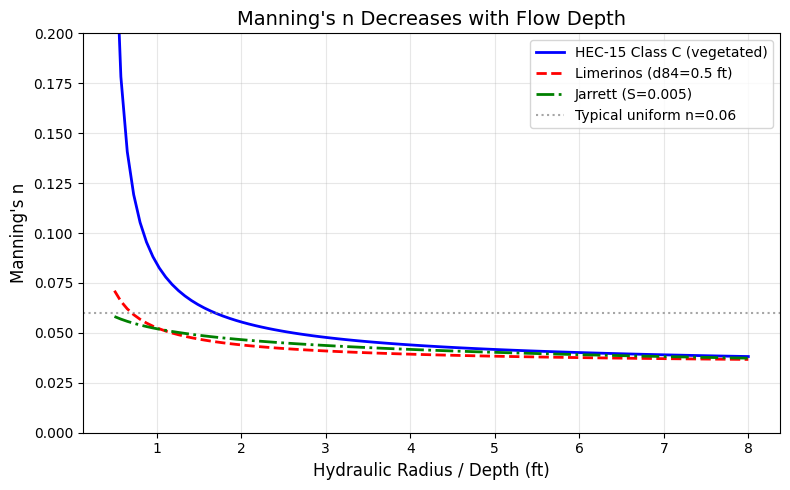

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plot Manning's n vs depth for three formulas ---
depths = np.linspace(0.5, 8.0, 100)  # ft
S = 0.005   # slope
d84 = 0.5   # ft (gravel bed)

# HEC-15 Class C (moderate retardance)
X_C = 30.2
n_hec15 = depths**(1/6) / (X_C + 19.97 * np.log10(depths**1.4 * S**0.4))
n_hec15 = np.clip(n_hec15, 0.01, 0.3)

# Limerinos (1970)
n_lim = (0.0926 * depths**(1/6)) / (1.16 + 2.0 * np.log10(depths / d84))
n_lim = np.clip(n_lim, 0.01, 0.3)

# Jarrett (1984)
n_jar = 0.39 * S**0.38 * depths**(-0.16)
n_jar = np.clip(n_jar, 0.01, 0.3)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, n_hec15, 'b-', linewidth=2, label='HEC-15 Class C (vegetated)')
ax.plot(depths, n_lim, 'r--', linewidth=2, label=f'Limerinos (d84={d84} ft)')
ax.plot(depths, n_jar, 'g-.', linewidth=2, label=f'Jarrett (S={S})')
ax.axhline(y=0.06, color='gray', linestyle=':', alpha=0.7, label='Typical uniform n=0.06')
ax.set_xlabel('Hydraulic Radius / Depth (ft)', fontsize=12)
ax.set_ylabel("Manning's n", fontsize=12)
ax.set_title("Manning's n Decreases with Flow Depth", fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.20)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from ras_commander import (
        init_ras_project, RasCmdr, RasExamples, ras,
        get_logger
    )
    from ras_commander.geom import GeomLandCover, GeomStorage
    from ras_commander.hdf import HdfMesh, HdfResultsMesh, HdfResultsPlan
except ImportError:
    current_file = Path(".").resolve()
    sys.path.append(str(current_file.parent))
    from ras_commander import (
        init_ras_project, RasCmdr, RasExamples, ras,
        get_logger
    )
    from ras_commander.geom import GeomLandCover, GeomStorage
    from ras_commander.hdf import HdfMesh, HdfResultsMesh, HdfResultsPlan

logger = get_logger(__name__)

## Configuration

In [3]:
PROJECT_NAME = "Muncie"
RAS_VERSION = "6.6"
PLAN_NUMBER = "03"          # Unsteady Run with 2D 50ft Grid (uses g02)
MESH_NAME = "2D Interior Area"
GEOM_NUMBER = "02"

# Depth-varying n parameters (exponential decay toward asymptote)
N_ASYMPTOTE = 0.045   # Deep-flow Manning's n
DEPTH_HALF = 1.0      # Depth at which n decays to ~37% of excess above asymptote

## Step 1: Extract Baseline and Modified Projects

We extract two independent copies of Muncie so the baseline stays pristine.

In [4]:
baseline_path = RasExamples.extract_project(PROJECT_NAME, suffix="414_baseline")
modified_path = RasExamples.extract_project(PROJECT_NAME, suffix="414_modified")

print(f"Baseline: {baseline_path}")
print(f"Modified: {modified_path}")

baseline_ras = init_ras_project(baseline_path, RAS_VERSION, ras_object="new")
plan_row = baseline_ras.plan_df[baseline_ras.plan_df['plan_number'] == PLAN_NUMBER].iloc[0]
print(f"\nPlan {PLAN_NUMBER}: {plan_row['Plan Title']}")
print(f"Geometry: g{str(plan_row['geometry_number']).zfill(2)}")

2026-05-22 21:39:05 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to G:\GH\ras-commander\examples\example_projects\Muncie_414_baseline


2026-05-22 21:39:05 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to G:\GH\ras-commander\examples\example_projects\Muncie_414_modified


2026-05-22 21:39:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-05-22 21:39:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-05-22 21:39:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


...

2026-05-22 21:39:05 - ras_commander.RasPrj - INFO - ras-commander v0.91.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-05-22 21:39:05 - ras_commander.RasPrj - INFO - Project initialized: Muncie | Folder: G:\GH\ras-commander\examples\example_projects\Muncie_414_baseline


2026-05-22 21:39:05 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


2026-05-22 21:39:05 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras_object.plan_df        Plans, HDF paths, geometry/flow associations
  ras_object.geom_df        Geometry files and HDF preprocessor paths
  ras_object.flow_df        Steady flow files
  ras_object.unsteady_df    Unsteady flow files and configurations
  ras_object.boundaries_df  Boundary conditions (type, name, location)
  ras_object.results_df     Lightweight HDF results summaries
  ras_object.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / c

Baseline: G:\GH\ras-commander\examples\example_projects\Muncie_414_baseline
Modified: G:\GH\ras-commander\examples\example_projects\Muncie_414_modified

Plan 03: Unsteady Run with 2D 50ft Grid
Geometry: g02


## Step 2: Read Current Manning's n Settings

Muncie uses a **uniform** Manning's n (0.06) for the entire 2D flow area.
The land cover table exists but is inactive because *Spatially Varied Manning's
on Faces* is disabled.

In [5]:
baseline_geom = baseline_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}"
modified_geom = modified_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}"

settings = GeomStorage.get_2d_flow_area_settings(baseline_geom)
area_row = settings[settings['name'] == MESH_NAME].iloc[0]
original_n = area_row['mannings_n']
spatially_varied = area_row.get('spatially_varied_mann_on_faces', False)

print(f"2D Flow Area: '{MESH_NAME}'")
print(f"  Uniform Manning's n: {original_n}")
print(f"  Spatially varied: {spatially_varied}")

original_mannings = GeomLandCover.get_base_mannings_n(baseline_geom)
print(f"\nLand cover table ({len(original_mannings)} classes):")
print(original_mannings.to_string(index=False))

2D Flow Area: '2D Interior Area'
  Uniform Manning's n: 0.06
  Spatially varied: False

Land cover table (7 classes):
Table Number            Land Cover Name  Base Mannings n Value
           7                     NoData                   0.06
           7                   Building                  10.00
           7 Medium Density Residential                   0.08
           7                 Open Space                   0.04
           7                       Park                   0.06
           7                      Trees                   0.12
           7                      Urban                   0.10


## Step 3: Preprocess Geometry

We run both projects with `force_geompre=True` to generate the geometry HDF
files containing face property tables. The baseline stays pristine for
comparison; we'll modify the face tables in the modified copy.

In [6]:
baseline_ras = init_ras_project(baseline_path, RAS_VERSION, ras_object="new")
print("Preprocessing baseline geometry...")
RasCmdr.compute_plan(PLAN_NUMBER, ras_object=baseline_ras, num_cores=2, force_geompre=True)
baseline_ras = init_ras_project(baseline_path, RAS_VERSION, ras_object="new")

modified_ras = init_ras_project(modified_path, RAS_VERSION, ras_object="new")
print("Preprocessing modified geometry...")
RasCmdr.compute_plan(PLAN_NUMBER, ras_object=modified_ras, num_cores=2, force_geompre=True)
modified_ras = init_ras_project(modified_path, RAS_VERSION, ras_object="new")

baseline_geom_hdf = baseline_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}.hdf"
modified_geom_hdf = modified_path / f"{modified_ras.project_name}.g{GEOM_NUMBER}.hdf"

print(f"\nBaseline HDF: {baseline_geom_hdf.name}")
print(f"Modified HDF: {modified_geom_hdf.name}")

2026-05-22 21:39:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-05-22 21:39:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-05-22 21:39:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-05-22 21:39:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


2026-05-22 21:39:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.2 at C:\Program Files (x86)\HEC\HEC-RAS\6.2\Ras.exe via filesystem (x86)


...

2026-05-22 21:40:08 - ras_commander.RasPrj - INFO - ras-commander v0.91.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-05-22 21:40:08 - ras_commander.RasPrj - INFO - Project initialized: Muncie | Folder: G:\GH\ras-commander\examples\example_projects\Muncie_414_modified


2026-05-22 21:40:08 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


2026-05-22 21:40:08 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras_object.plan_df        Plans, HDF paths, geometry/flow associations
  ras_object.geom_df        Geometry files and HDF preprocessor paths
  ras_object.flow_df        Steady flow files
  ras_object.unsteady_df    Unsteady flow files and configurations
  ras_object.boundaries_df  Boundary conditions (type, name, location)
  ras_object.results_df     Lightweight HDF results summaries
  ras_object.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / c


Baseline HDF: Muncie.g02.hdf
Modified HDF: Muncie.g02.hdf


## Step 4: Read Baseline Face Property Tables

The face property tables encode Manning's n as a function of elevation for
each cell face. After preprocessing with uniform n=0.06, every face has the
same constant roughness at all elevations. We'll visualize this structure
before applying depth-varying modifications.

Faces: 11164
Total rows: 47055
Uniform n: 0.0600


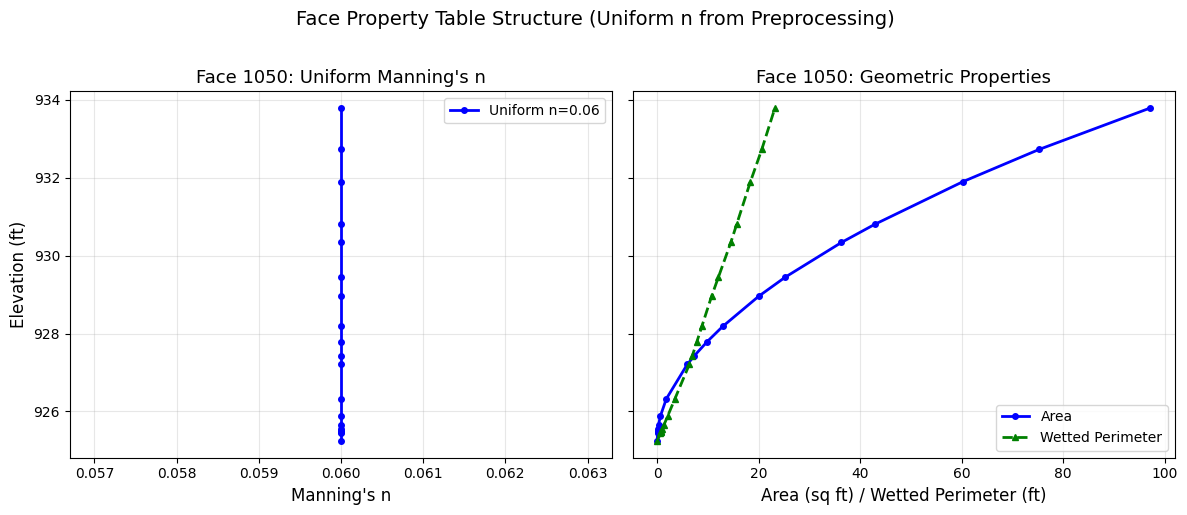

In [7]:
base_tables = HdfMesh.get_mesh_face_property_tables(baseline_geom_hdf)
base_df = base_tables[MESH_NAME]
n_col = "Manning's n"
sample_face = 1050

print(f"Faces: {base_df['Face ID'].nunique()}")
print(f"Total rows: {len(base_df)}")
print(f"Uniform n: {base_df[n_col].mean():.4f}")

sample_df = base_df[base_df['Face ID'] == sample_face]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax = axes[0]
ax.plot(sample_df[n_col], sample_df['Elevation'], 'b-o', markersize=4, linewidth=2,
        label=f'Uniform n={original_n}')
ax.set_xlabel("Manning's n", fontsize=12)
ax.set_ylabel('Elevation (ft)', fontsize=12)
ax.set_title(f'Face {sample_face}: Uniform Manning\'s n', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(sample_df['Area'], sample_df['Elevation'], 'b-o', markersize=4, linewidth=2,
        label='Area')
ax.plot(sample_df['Wetted Perimeter'], sample_df['Elevation'], 'g--^', markersize=4,
        linewidth=2, label='Wetted Perimeter')
ax.set_xlabel('Area (sq ft) / Wetted Perimeter (ft)', fontsize=12)
ax.set_title(f'Face {sample_face}: Geometric Properties', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('Face Property Table Structure (Uniform n from Preprocessing)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Step 5: Apply Depth-Varying Manning's n

Instead of uniform roughness, we apply a physically-based formula where n
**decreases with flow depth** â€” consistent with HEC-15 and Limerinos. We use
an exponential decay model:

$$n(d) = n_{\text{asymptote}} + (n_{\text{base}} - n_{\text{asymptote}}) \cdot e^{-d/d_{1/2}}$$

This captures the key physics: at shallow depths, n equals the base value
(set during preprocessing). As depth increases, n decays toward the asymptote.

We apply this to the modified project's **already-preprocessed** geometry HDF
using `HdfMesh.set_face_mannings_n_values()`, which replaces the n column in
each face's property table while preserving elevation, area, and wetted perimeter.

2026-05-22 21:40:10 - ras_commander.hdf.HdfMesh - INFO - Wrote face property tables for 11164 faces in mesh '2D Interior Area' (47055 total rows)


2026-05-22 21:40:10 - ras_commander.hdf.HdfMesh - INFO - Modified Manning's n for 11164 faces in mesh '2D Interior Area'


C:\Users\bill\AppData\Local\Temp\ipykernel_32504\264333612.py:42: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Applied depth-varying n to 11164 faces


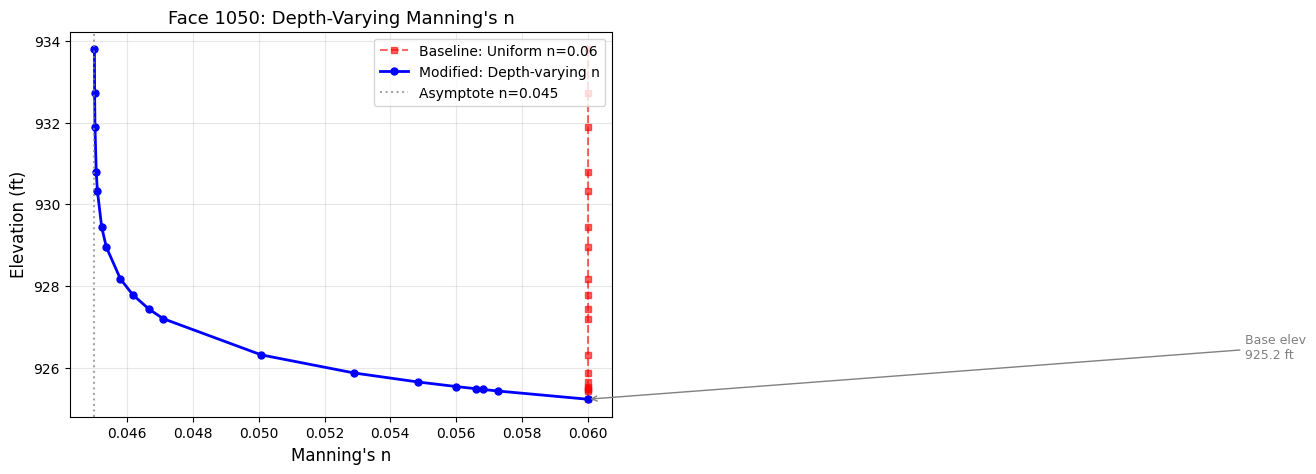


n at base (d=0):   0.0600
n at top  (d=8.6 ft): 0.0450


In [8]:
def vegetal_retardance(elevation, depth, current_n):
    """Exponential decay: n decreases from current_n toward N_ASYMPTOTE with depth."""
    if depth <= 0:
        return current_n
    return N_ASYMPTOTE + (current_n - N_ASYMPTOTE) * np.exp(-depth / DEPTH_HALF)

num_modified = HdfMesh.set_face_mannings_n_values(
    hdf_path=modified_geom_hdf,
    mesh_name=MESH_NAME,
    mannings_n_func=vegetal_retardance,
    face_ids=None,
    pin_tables=False,
)
print(f"Applied depth-varying n to {num_modified} faces")

# Read back and compare baseline vs depth-varying for sample face
after_tables = HdfMesh.get_mesh_face_property_tables(modified_geom_hdf)
after_df = after_tables[MESH_NAME]
after_sample = after_df[after_df['Face ID'] == sample_face]
base_sample = base_df[base_df['Face ID'] == sample_face]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(base_sample[n_col], base_sample['Elevation'], 'r--s', markersize=4,
        label=f'Baseline: Uniform n={original_n}', linewidth=1.5, alpha=0.6)
ax.plot(after_sample[n_col], after_sample['Elevation'], 'b-o', markersize=5,
        label='Modified: Depth-varying n', linewidth=2)
ax.axvline(x=N_ASYMPTOTE, color='gray', linestyle=':', alpha=0.7,
           label=f'Asymptote n={N_ASYMPTOTE}')

base_elev = after_sample['Elevation'].iloc[0]
ax.annotate(f'Base elev\n{base_elev:.1f} ft',
            xy=(after_sample[n_col].iloc[0], base_elev),
            xytext=(after_sample[n_col].iloc[0] + 0.02, base_elev + 1),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

ax.set_xlabel("Manning's n", fontsize=12)
ax.set_ylabel('Elevation (ft)', fontsize=12)
ax.set_title(f'Face {sample_face}: Depth-Varying Manning\'s n', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"\nn at base (d=0):   {after_sample[n_col].iloc[0]:.4f}")
print(f"n at top  (d={after_sample['Elevation'].iloc[-1] - base_elev:.1f} ft): {after_sample[n_col].iloc[-1]:.4f}")

## Step 6: Extend Tables to Higher Elevations

The preprocessed face tables only reach the terrain elevation at each face.
For deep flood events, water may rise above this â€” and HEC-RAS extrapolates
with the last n value (constant, not depth-varying).

`HdfMesh.extend_face_property_tables()` appends rows from the current maximum
up to a target elevation, using a rectangular cross-section assumption for
area and wetted perimeter. The Manning's n function receives `(depth, base_n)`
so it can implement any depth-varying formula.

2026-05-22 21:40:12 - ras_commander.hdf.HdfMesh - INFO - Pinned property tables for mesh '2D Interior Area'


2026-05-22 21:40:12 - ras_commander.hdf.HdfMesh - INFO - Wrote face property tables for 11164 faces in mesh '2D Interior Area' (476525 total rows)


2026-05-22 21:40:12 - ras_commander.hdf.HdfMesh - INFO - Extended 11164 face tables in mesh '2D Interior Area', total rows added: 429470


Extended 11164 faces, total rows added: 429470


Face 1050: 19 rows -> 71 rows
Elevation range: 925.24 - 959.79 ft


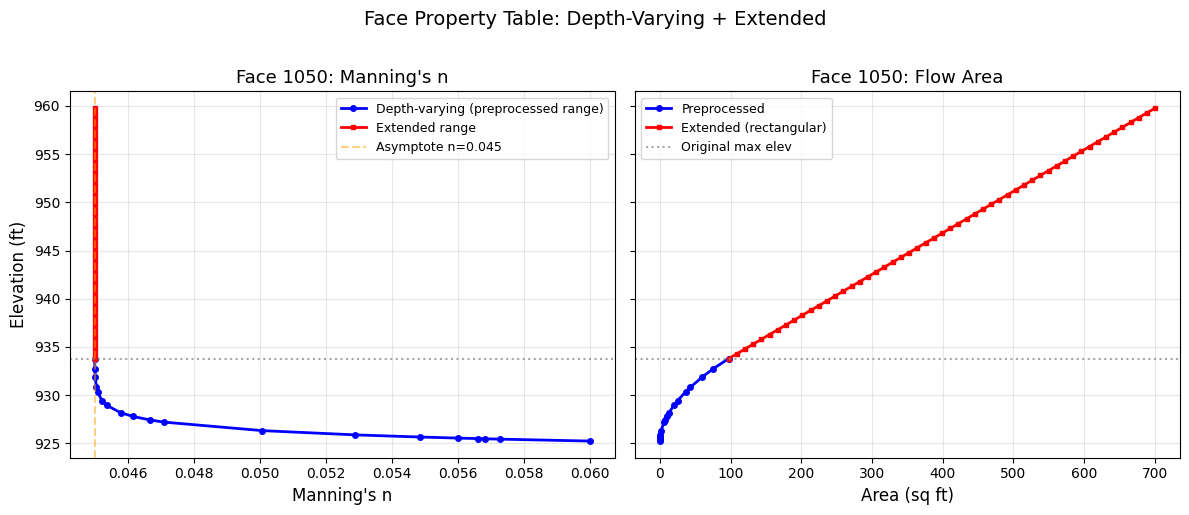

In [9]:
max_elev = base_df['Elevation'].max()
target_elev = max_elev + 5.0

def extend_n_func(depth, base_n):
    """Manning's n for extension rows (same exponential decay)."""
    if depth <= 0:
        return base_n
    return N_ASYMPTOTE + (base_n - N_ASYMPTOTE) * np.exp(-depth / DEPTH_HALF)

rows_added = HdfMesh.extend_face_property_tables(
    hdf_path=modified_geom_hdf,
    mesh_name=MESH_NAME,
    extension_elevation=target_elev,
    mannings_n_func=extend_n_func,
    elevation_step=0.5,
    face_ids=None,
    pin_tables=True,
)

print(f"Extended {len(rows_added)} faces, total rows added: {sum(rows_added.values())}")

ext_tables = HdfMesh.get_mesh_face_property_tables(modified_geom_hdf)
ext_df = ext_tables[MESH_NAME]
ext_sample = ext_df[ext_df['Face ID'] == sample_face]

print(f"Face {sample_face}: {len(after_sample)} rows -> {len(ext_sample)} rows")
print(f"Elevation range: {ext_sample['Elevation'].min():.2f} - {ext_sample['Elevation'].max():.2f} ft")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax = axes[0]
orig_max_elev = after_sample['Elevation'].max()
orig_portion = ext_sample[ext_sample['Elevation'] <= orig_max_elev + 0.01]
ext_portion = ext_sample[ext_sample['Elevation'] > orig_max_elev - 0.01]

ax.plot(orig_portion[n_col], orig_portion['Elevation'], 'b-o', markersize=4,
        label='Depth-varying (preprocessed range)', linewidth=2)
ax.plot(ext_portion[n_col], ext_portion['Elevation'], 'r-s', markersize=3,
        label='Extended range', linewidth=2)
ax.axhline(y=orig_max_elev, color='gray', linestyle=':', alpha=0.7)
ax.axvline(x=N_ASYMPTOTE, color='orange', linestyle='--', alpha=0.5,
           label=f'Asymptote n={N_ASYMPTOTE}')
ax.set_xlabel("Manning's n", fontsize=12)
ax.set_ylabel('Elevation (ft)', fontsize=12)
ax.set_title(f"Face {sample_face}: Manning's n", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(orig_portion['Area'], orig_portion['Elevation'], 'b-o', markersize=4,
        label='Preprocessed', linewidth=2)
ax.plot(ext_portion['Area'], ext_portion['Elevation'], 'r-s', markersize=3,
        label='Extended (rectangular)', linewidth=2)
ax.axhline(y=orig_max_elev, color='gray', linestyle=':', alpha=0.7,
           label=f'Original max elev')
ax.set_xlabel('Area (sq ft)', fontsize=12)
ax.set_title(f'Face {sample_face}: Flow Area', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Face Property Table: Depth-Varying + Extended', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Step 7: Limiting Modifications to an Override Region

In practice, depth-varying Manning's n is most meaningful in the **channel** â€”
overbank areas may have vegetation or land cover that already captures the
roughness variation you care about. The API supports three spatial filtering
strategies, listed in precedence order:

| Parameter | Source | Use Case |
|-----------|--------|----------|
| `face_ids` | Pre-computed list of face IDs | Full control â€” any selection logic |
| `region_name` | Named calibration region in the geometry HDF | Drawn in RASMapper; recommended for repeatable workflows |
| `polygon` | Any Shapely polygon | Programmatic selection from external GIS data, bank lines, or classification results |

When any of these parameters is passed to `extend_face_property_tables()` or
`set_face_mannings_n_values()`, only the matching faces are modified â€” all
other faces retain their original property tables.

### Calibration Regions (Recommended)

The simplest approach is to draw a **calibration region** in RASMapper that
covers the channel corridor, then reference it by name:

```python
HdfMesh.extend_face_property_tables(
    hdf_path=geom_hdf,
    mesh_name="Your 2D Area",
    extension_elevation=960.0,
    mannings_n_func=my_n_func,
    region_name="Main Channel",   # drawn in RASMapper
    pin_tables=True,
)
```

This is preferred because the region persists in the geometry file, is visible
in the GUI, and doesn't depend on simulation results.

### Other Channel Delineation Approaches

For models where a calibration region isn't already defined, the channel
polygon can be derived programmatically:

- **Bank lines** â€” `HdfXsec.get_river_bank_lines()` extracts 1D bank line
  geometry from the HDF, which can be buffered or connected into a channel polygon.
- **External GIS** â€” FEMA NFHL floodway boundaries, NHD flowlines, or any
  shapefile/GeoJSON polygon can be loaded with GeoPandas and passed as the
  `polygon` parameter.

The Muncie example project is too small to meaningfully demonstrate selective
application â€” the channel dominates the domain, so nearly all faces would be
selected. In a real project with a large overbank area, the difference between
channel-only and full-mesh modification would be significant.

## Summary

This notebook demonstrated a complete workflow for depth-varying Manning's n
in HEC-RAS 2D models:

### What We Showed

1. **Literature basis**: Manning's n decreases with flow depth â€” established by
   HEC-15, Limerinos (1970), Jarrett (1984), and Chow (1959)
2. **Geometry preprocessing**: Ran with `force_geompre=True` to generate face
   property tables from the uniform Manning's n in the plain-text geometry
3. **Depth-varying n**: Applied an exponential decay formula to the face property
   tables using `HdfMesh.set_face_mannings_n_values()`
4. **Table extension**: Extended face tables above terrain elevation using
   `HdfMesh.extend_face_property_tables()` with depth-varying Manning's n
5. **Spatial filtering**: Described how `region_name`, `polygon`, and `face_ids`
   parameters limit modifications to specific faces (e.g., channel only)

### Key Architecture Points

| Workflow | Method |
|----------|--------|
| Persist n through compute | Modify `.g##` via `GeomStorage` + `force_geompre=True` |
| Direct HDF modification | `HdfMesh.set_face_mannings_n_values()` (analysis only) |
| Extend tables higher | `HdfMesh.extend_face_property_tables()` |
| Protect from RASMapper | `HdfMesh.pin_property_tables()` (but NOT from preprocessor) |
| Spatial filtering | `polygon=`, `region_name=`, or `face_ids=` parameters |

### Adapting for Your Project

```python
# 1. Extract your project (or point to your local copy)
ras = init_ras_project("/path/to/your/project", "7.0")

# 2. Run with force_geompre to generate face tables
RasCmdr.compute_plan("01", ras_object=ras, force_geompre=True)
ras = init_ras_project("/path/to/your/project", "7.0", ras_object="new")

# 3. Define your depth-varying n function
def my_n_func(depth, base_n):
    if depth <= 0: return base_n
    return 0.035 + (base_n - 0.035) * np.exp(-depth / 1.5)

# 4. Extend channel faces only (using calibration region)
geom_hdf = Path(ras.geom_df.iloc[0]['file_path']).with_suffix('.hdf')
HdfMesh.extend_face_property_tables(
    hdf_path=geom_hdf,
    mesh_name="Your 2D Area",
    extension_elevation=960.0,  # target elevation
    mannings_n_func=my_n_func,
    region_name="Channel",      # drawn in RASMapper
    pin_tables=True,
)
```

### References

- Chow, V.T., 1959. *Open-Channel Hydraulics*. McGraw-Hill.
- FHWA, 2005. *Design of Roadside Channels with Flexible Linings* (HEC-15). FHWA-NHI-05-114.
- Limerinos, J.T., 1970. USGS Water-Supply Paper 1898-B.
- Jarrett, R.D., 1984. *J. Hydraulic Engineering*, ASCE, 110(11): 1519-1539.
- [HEC-RAS Technical Reference â€” Energy Loss Coefficients](https://www.hec.usace.army.mil/confluence/rasdocs/ras1dtechref/6.6/basic-data-requirements/geometric-data/energy-loss-coefficients)
- [HEC-RAS 2D â€” Face Property Tables](https://www.hec.usace.army.mil/confluence/rasdocs/r2dum/latest/development-of-a-2d-or-combined-1d-2d-model/creating-hydraulic-property-tables-for-2d-flow-areas)